# 03 — Fold Validation

Validates the 5-fold CV splits generated by `src/data/make_folds.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

FOLDS_CSV = '../data/folds/folds.csv'
TRAIN_CSV = '../data/raw/train.csv'

folds = pd.read_csv(FOLDS_CSV)
meta = pd.read_csv(TRAIN_CSV)
df = folds.merge(meta[['filename','collection']], on='filename', how='left') if 'collection' in meta.columns else folds.copy()
N_FOLDS = df['fold'].nunique()
all_species = sorted(df['primary_label'].unique())
print(f'{len(df)} samples, {len(all_species)} species, {N_FOLDS} folds')

35549 samples, 206 species, 5 folds


## 1 — Samples per fold

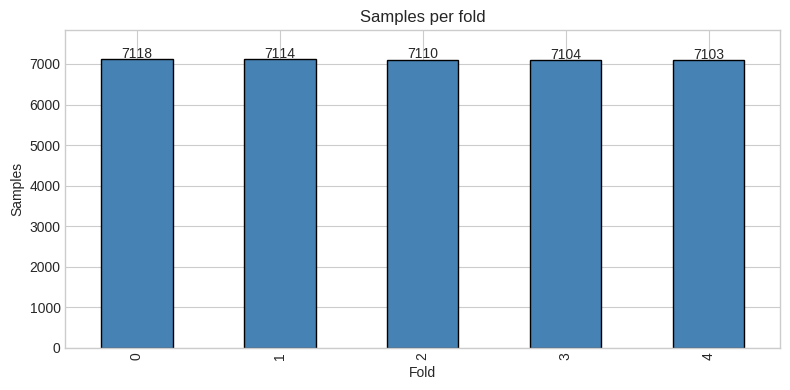

Imbalance: 0.2% (max-min)/mean


In [2]:
fold_counts = df['fold'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
fold_counts.plot.bar(ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Fold')
ax.set_ylabel('Samples')
ax.set_title('Samples per fold')
for i, v in enumerate(fold_counts):
    ax.text(i, v + 30, str(v), ha='center', fontsize=10)
ax.set_ylim(0, fold_counts.max() * 1.1)
plt.tight_layout()
plt.show()

imbalance = (fold_counts.max() - fold_counts.min()) / fold_counts.mean() * 100
print(f'Imbalance: {imbalance:.1f}% (max-min)/mean')

## 2 — Species coverage per fold (validation set)

In [3]:
coverage = {}
missing_species = {}
for fold_id in range(N_FOLDS):
    val_sp = set(df[df['fold'] == fold_id]['primary_label'].unique())
    coverage[fold_id] = len(val_sp)
    missing_species[fold_id] = sorted(set(all_species) - val_sp)

cov_df = pd.DataFrame({'fold': list(coverage.keys()), 'species_in_val': list(coverage.values())})
cov_df['missing'] = [len(missing_species[f]) for f in range(N_FOLDS)]
print(cov_df.to_string(index=False))

if all(v == 0 for v in cov_df['missing']):
    print('\n✓ Every species appears in every fold.')
else:
    for f in range(N_FOLDS):
        if missing_species[f]:
            print(f'\nFold {f} missing: {missing_species[f]}')

 fold  species_in_val  missing
    0             206        0
    1             202        4
    2             199        7
    3             193       13
    4             192       14

Fold 1 missing: ['116570', '23150', '23724', '516975']

Fold 2 missing: ['116570', '209233', '23150', '23724', '24321', '516975', '70711']

Fold 3 missing: ['116570', '209233', '23150', '23724', '24321', '25214', '476521', '516975', '555123', '64898', '70711', '74580', 'sptnig1']

Fold 4 missing: ['116570', '209233', '23150', '23176', '23724', '24321', '25214', '476521', '516975', '555123', '64898', '70711', '74580', 'sptnig1']


## 3 — Fold × Collection source

collection    XC  iNat
fold                  
0           4618  2500
1           4599  2515
2           4644  2466
3           4560  2544
4           4622  2481

Proportions:
collection    XC  iNat
fold                  
0           64.9  35.1
1           64.6  35.4
2           65.3  34.7
3           64.2  35.8
4           65.1  34.9


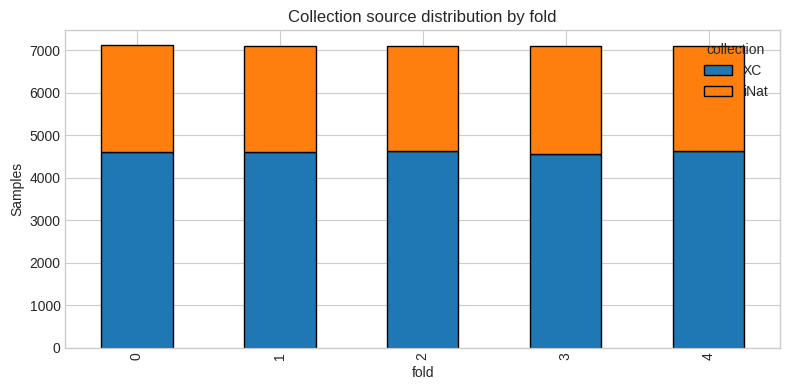

In [4]:
if 'collection' in df.columns:
    ct = pd.crosstab(df['fold'], df['collection'])
    print(ct)
    print()
    print('Proportions:')
    print((ct.div(ct.sum(axis=1), axis=0) * 100).round(1))

    ct.plot.bar(stacked=True, figsize=(8, 4), edgecolor='black')
    plt.title('Collection source distribution by fold')
    plt.ylabel('Samples')
    plt.tight_layout()
    plt.show()
else:
    print('No collection column.')

## 4 — Rarest 10 species: fold assignments

In [5]:
species_counts = df['primary_label'].value_counts()
rarest = species_counts.tail(10).index.tolist()

rows = []
for sp in rarest:
    sub = df[df['primary_label'] == sp]
    fold_dist = sub['fold'].value_counts().sort_index().to_dict()
    row = {'species': sp, 'total': len(sub)}
    for f in range(N_FOLDS):
        row[f'fold_{f}'] = fold_dist.get(f, 0)
    rows.append(row)

rare_df = pd.DataFrame(rows)
print(rare_df.to_string(index=False))

species  total  fold_0  fold_1  fold_2  fold_3  fold_4
  64898      3       1       1       1       0       0
  74580      3       1       1       1       0       0
sptnig1      3       1       1       1       0       0
 209233      2       1       1       0       0       0
  24321      2       1       1       0       0       0
  70711      2       1       1       0       0       0
 116570      1       1       0       0       0       0
  23150      1       1       0       0       0       0
  23724      1       1       0       0       0       0
 516975      1       1       0       0       0       0


## 5 — Verdict

**Checklist:**
- [ ] Folds roughly equal in size
- [ ] All species present in every fold's validation set (or acknowledged)
- [ ] Collection sources spread, not concentrated
- [ ] Rare species distributed across folds (training coverage)

_Fill in after running: **Folds are sound / Concerns: …**_